In [7]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
import seaborn as sns

In [8]:
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df[housing.target_names[0]] = housing.target
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [9]:
df.isna().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

<Axes: xlabel='HouseAge', ylabel='AveRooms'>

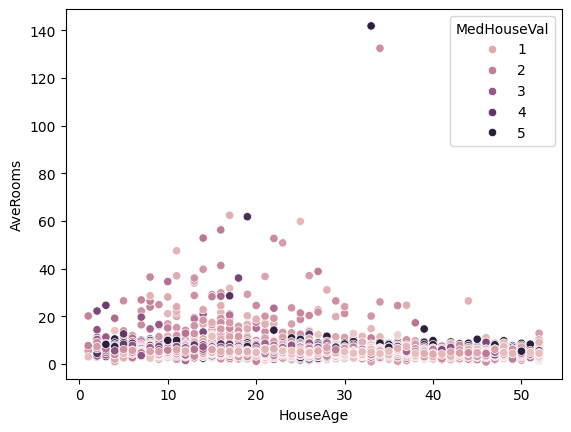

In [10]:
sns.scatterplot(x=df["HouseAge"], y=df["AveRooms"], hue=df["MedHouseVal"])

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print("r-squared: ",r2*100,"%")

n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - ((1-r2) * (n-1)/(n-p-1))
print("adjusted r^2 value: ", adjusted_r2)

r-squared:  57.578770603245076 %
adjusted r^2 value:  0.5749637928613558


In [24]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
import logging
import joblib
import os

CONFIG = {
    "test_size": 0.2,
    "random_state": 42,
    "target_col": "MedHouseVal",
    "model_path": "models/model.joblib"
}

class ModelNotFitted(Exception):
    """Error caused by not model not fitted perfectly"""
    pass

class LinearRegressionModel:
    def __init__(self, config: dict) -> None:
        self.config = config
        self.pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression())
        ])

        self.is_fitted = False

    def train(self, X_train, y_train) -> None:
        self.pipeline.fit(X_train, y_train)
        
        trained_regression = self.pipeline.named_steps['model']
        
        coefficients = trained_regression.coef_
        intercept = trained_regression.intercept_
        logging.info(f"coefficients: {coefficients}")
        logging.info(f"Intercept: {intercept}")
        self.is_fitted = True

    def predict(self, X) -> np.ndarray:
        if not self.is_fitted:
            raise ModelNotFitted("Please train your model first!!")
        return self.pipeline.predict(X)

    def save(self, path: str) -> None:
        os.makedirs(os.path.dirname(path), exist_ok=True)
        artifact = {
            "pipeline": self.pipeline,
            "config": self.config
        }
        joblib.dump(artifact, path)
        logging.info(f"Model saved into {path}")


    @classmethod
    def load(cls, path: str) -> "LinearRegressionModel":
        artifact = joblib.load(path)
        instance = cls(config=artifact["config"])
        instance.pipeline = artifact["pipeline"]
        instance.is_fitted = True
        return instance


if __name__ == "__main__":
    logging.basicConfig(
        level=logging.INFO, 
        format="%(asctime)s %(levelname)s — %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S"
    )

    housing = fetch_california_housing(as_frame=True)
    df = housing.frame
    logging.info(f"Data loaded: {df.shape[0]} rows, {df.shape[1] - 1} features")

    X = df.drop(columns=[CONFIG["target_col"]])
    y = df[CONFIG["target_col"]]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=CONFIG["test_size"], 
        random_state=CONFIG["random_state"]
    )

    logging.info(f"Train/test split: {len(X_train)} train / {len(X_test)} test (test_size={CONFIG['test_size']}, seed={CONFIG['random_state']})")

    my_model = LinearRegressionModel(config=CONFIG)
    my_model.train(X_train, y_train)
    
    pred_before = my_model.predict(X_test)
    logging.info(f"Prediction before save, first 5 {pred_before[:5]}")

    my_model.save(CONFIG["model_path"])

    reloaded_model = LinearRegressionModel.load(CONFIG["model_path"])
    preds_after = reloaded_model.predict(X_test)
    logging.info(f"Predictions after reload (first 5): {preds_after[:5]}")

    match = np.allclose(pred_before, preds_after)
    logging.info(f"Predictions identical before/after reload: {match}")

2026-09-12 21:23:24 INFO — Data loaded: 20640 rows, 8 features
2026-09-12 21:23:24 INFO — Train/test split: 16512 train / 4128 test (test_size=0.2, seed=42)
2026-09-12 21:23:24 INFO — coefficients: [ 0.85438303  0.12254624 -0.29441013  0.33925949 -0.00230772 -0.0408291
 -0.89692888 -0.86984178]
2026-09-12 21:23:24 INFO — Intercept: 2.071946937378881
2026-09-12 21:23:24 INFO — Prediction before save, first 5 [0.71912284 1.76401657 2.70965883 2.83892593 2.60465725]
2026-09-12 21:23:24 INFO — Model saved into models/model.joblib
2026-09-12 21:23:24 INFO — Predictions after reload (first 5): [0.71912284 1.76401657 2.70965883 2.83892593 2.60465725]
2026-09-12 21:23:24 INFO — Predictions identical before/after reload: True


In [32]:
import numpy as np
import logging
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

class MissmatchedLengthError(Exception):
    """This is raised, when y_true and y_pred dont match samples"""
    pass

def evaluate_regression(y_true, y_pred, n_features: int) -> dict:
    if len(y_true) != len(y_pred):
        raise MissmatchedLengthError(f"y_true has {len(y_true)} samples, y_pred has {len(y_pred)} — cannot evaluate.")


    n_samples = len(y_true)
    p = n_features
    
    mae = float(mean_absolute_error(y_true, y_pred))
    mse = float(mean_squared_error(y_true, y_pred))
    rmse = float(mse ** 0.5)
    r2 = float(r2_score(y_true, y_pred))
    adj_r2 = float(1 - ((1 - r2) * (n_samples - 1) / (n_samples - p - 1)))

    result = {
        "mae": mae,
        "mse": mse,
        "rmse": rmse,
        "r2": r2,
        "adj_r2": adj_r2
    }

    logging.info(f"METRICS: {result}")
    return result


MissmatchedLengthError: y_true has 6 samples, y_pred has 5 — cannot evaluate.